# 09 — CPS Heterogeneity Analysis

This notebook tests whether the minimum wage employment effects differ across demographic groups —
specifically by **age group** and **gender**. Low-wage workers (teens, young adults, women)
are more likely to be minimum wage earners and therefore more likely to be affected.

**Design:** We merge the CPS state-level employment rates with the minimum wage panel and
run state-level DiD regressions (state FE + year FE) separately for each demographic group.
This is a complementary analysis to the border-county QCEW design — it uses a different
data source to probe *who* is affected.

**Inputs:**
- `data/intermediate/cps_panel.parquet` — state × year × age_group × gender employment rates
- `data/intermediate/min_wage_panel.parquet` — state × year minimum wages

**Specifications run:**
1. By age group (all workers, both genders combined)
2. By gender (all ages 16–64)
3. By age group × gender interaction
4. Focus on teens (16–19) and young adults (20–24) — the most exposed groups

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

ROOT = Path().resolve().parent
INTERMEDIATE = ROOT / "data" / "intermediate"
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

CPS_FILE = INTERMEDIATE / "cps_panel.parquet"
MW_FILE = INTERMEDIATE / "min_wage_panel.parquet"

FIRST_YEAR = 2004
LAST_YEAR = 2024

## 1. Load and merge inputs

In [10]:
cps = pd.read_parquet(CPS_FILE)
mw = pd.read_parquet(MW_FILE)

print("CPS panel shape :", cps.shape)
print("MW panel shape  :", mw.shape)
print("\nCPS columns:", cps.columns.tolist())
print("MW columns :", mw.columns.tolist())
print("\nAge groups in CPS:")
print(sorted(cps["age_group"].unique()))

CPS panel shape : (19278, 7)
MW panel shape  : (1113, 4)

CPS columns: ['state_fips', 'year', 'age_group', 'female', 'emp_rate', 'n_individuals', 'total_weight']
MW columns : ['state', 'state_fips', 'year', 'min_wage']

Age groups in CPS:
['16-19', '20-24', '25-34', '35-44', '45-54', '55-64']


In [11]:
# Filter to analysis years
cps = cps[cps["year"].between(FIRST_YEAR, LAST_YEAR)].copy()
mw = mw[mw["year"].between(FIRST_YEAR, LAST_YEAR)].copy()

# Merge min wage onto CPS via state_fips × year
merged = cps.merge(
    mw[["state_fips", "year", "min_wage", "state"]],
    on=["state_fips", "year"],
    how="left",
)

# Log minimum wage
merged["log_min_wage"] = np.log(merged["min_wage"])
merged["log_emp_rate"] = np.log(merged["emp_rate"].clip(lower=0.001))  # avoid log(0)

unmatched = merged["min_wage"].isna().sum()
print(f"Rows after merge    : {len(merged):,}")
print(f"Unmatched (no MW)   : {unmatched:,}  (should be 0)")
merged.head()

Rows after merge    : 19,278
Unmatched (no MW)   : 126  (should be 0)


,state_fips,year,age_group,female,emp_rate,n_individuals,total_weight,min_wage,state,log_min_wage,log_emp_rate
0,01,2004,16-19,0,0.824236,28,45902.84,5.15,AL,1.638997,-0.193298
1,01,2004,16-19,1,0.923777,39,51035.57,5.15,AL,1.638997,-0.079284
2,01,2004,20-24,0,0.894170,59,114027.51,5.15,AL,1.638997,-0.111859
3,01,2004,20-24,1,0.807976,66,119515.71,5.15,AL,1.638997,-0.213223
4,01,2004,25-34,0,0.950883,155,247350.31,5.15,AL,1.638997,-0.050364


## 2. Helper: run state + year FE regression

For the CPS analysis we use a simpler specification than the border-county design:
**state fixed effects + year fixed effects**, with standard errors clustered at the state level.

$$\log(emp\_rate_{st}) = \beta \log(mw_{st}) + \alpha_s + \delta_t + \varepsilon_{st}$$

In [12]:
def run_twfe(
    df,
    y_col="log_emp_rate",
    x_col="log_min_wage",
    state_col="state_fips",
    year_col="year",
):
    """Two-way FE regression (state + year) with state-clustered SEs."""
    d = df[[y_col, x_col, state_col, year_col]].dropna().copy()

    # Demean by state
    d["y_dm"] = d[y_col] - d.groupby(state_col)[y_col].transform("mean")
    d["x_dm"] = d[x_col] - d.groupby(state_col)[x_col].transform("mean")

    # Demean by year
    d["y_dm"] = d["y_dm"] - d.groupby(year_col)["y_dm"].transform("mean")
    d["x_dm"] = d["x_dm"] - d.groupby(year_col)["x_dm"].transform("mean")

    fit = sm.OLS(d["y_dm"], d[["x_dm"]]).fit(
        cov_type="cluster",
        cov_kwds={"groups": d[state_col]},
    )

    return {
        "beta": float(fit.params["x_dm"]),
        "se": float(fit.bse["x_dm"]),
        "t_stat": float(fit.tvalues["x_dm"]),
        "p_value": float(fit.pvalues["x_dm"]),
        "n_obs": int(fit.nobs),
        "n_states": int(d[state_col].nunique()),
    }

## 3. Heterogeneity by age group

In [13]:
AGE_GROUPS = ["16-19", "20-24", "25-34", "35-44", "45-54", "55-64"]

# female == -1 means both genders combined
age_data = merged[merged["female"] == -1].copy()

age_results = []
for ag in AGE_GROUPS:
    sub = age_data[age_data["age_group"] == ag]
    res = run_twfe(sub)
    res["age_group"] = ag
    age_results.append(res)

age_results = pd.DataFrame(age_results)
for col in ["beta", "se", "t_stat", "p_value"]:
    age_results[col] = age_results[col].round(4)

age_results["sig"] = age_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by age group (log emp_rate ~ log min_wage):")
print(
    age_results[["age_group", "beta", "se", "p_value", "sig", "n_obs"]].to_string(
        index=False
    )
)

Employment elasticity by age group (log emp_rate ~ log min_wage):
age_group    beta     se  p_value sig  n_obs
    16-19  0.0431 0.0248   0.0815   *   1064
    20-24 -0.0281 0.0141   0.0459  **   1064
    25-34 -0.0057 0.0079   0.4733       1064
    35-44 -0.0037 0.0052   0.4752       1064
    45-54  0.0047 0.0058   0.4114       1064
    55-64  0.0078 0.0055   0.1586       1064


## 4. Heterogeneity by gender

In [14]:
gender_results = []
for female_val, label in [(0, "Male"), (1, "Female")]:
    # All age groups combined — use individual-level weighted data collapsed to state×year
    sub = merged[
        (merged["female"] == female_val)
        & (
            merged["age_group"] == "25-34"
        )  # pick one age group to avoid double-counting
    ]
    # Better: reload cps_clean and collapse by state×year×female
    gender_results.append({"gender": label, "note": "see age×gender table below"})

# Proper gender breakdown: use all age groups, female=0 vs female=1
# Collapse each state×year×female across all age groups (weighted mean)
cps_clean = pd.read_parquet(ROOT / "data" / "intermediate" / "cps_clean.parquet")
cps_clean = cps_clean[cps_clean["year"].between(FIRST_YEAR, LAST_YEAR)]


def weighted_emp(g):
    return np.average(g["employed"], weights=g["weight"])


gender_panel = (
    cps_clean.groupby(["state_fips", "year", "female"])
    .apply(weighted_emp)
    .reset_index()
    .rename(columns={0: "emp_rate"})
)
gender_panel = gender_panel.merge(
    mw[["state_fips", "year", "min_wage"]], on=["state_fips", "year"], how="left"
)
gender_panel["log_min_wage"] = np.log(gender_panel["min_wage"])
gender_panel["log_emp_rate"] = np.log(gender_panel["emp_rate"].clip(lower=0.001))

gender_results = []
for female_val, label in [(0, "Male"), (1, "Female")]:
    sub = gender_panel[gender_panel["female"] == female_val]
    res = run_twfe(sub)
    res["gender"] = label
    gender_results.append(res)

gender_results = pd.DataFrame(gender_results)
for col in ["beta", "se", "t_stat", "p_value"]:
    gender_results[col] = gender_results[col].round(4)
gender_results["sig"] = gender_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by gender:")
print(
    gender_results[["gender", "beta", "se", "p_value", "sig", "n_obs"]].to_string(
        index=False
    )
)

Employment elasticity by gender:
gender    beta     se  p_value sig  n_obs
  Male -0.0033 0.0065   0.6080       1064
Female  0.0009 0.0059   0.8849       1064


## 5. Age group × gender interaction

In [15]:
interaction_results = []
for ag in AGE_GROUPS:
    for female_val, gender_label in [(0, "Male"), (1, "Female")]:
        sub = merged[(merged["age_group"] == ag) & (merged["female"] == female_val)]
        if len(sub) < 50:
            continue
        res = run_twfe(sub)
        res["age_group"] = ag
        res["gender"] = gender_label
        interaction_results.append(res)

interaction_results = pd.DataFrame(interaction_results)
for col in ["beta", "se", "p_value"]:
    interaction_results[col] = interaction_results[col].round(4)
interaction_results["sig"] = interaction_results["p_value"].apply(
    lambda p: "***" if p < 0.01 else ("**" if p < 0.05 else ("*" if p < 0.1 else ""))
)

print("Employment elasticity by age group × gender:")
print(
    interaction_results[
        ["age_group", "gender", "beta", "se", "p_value", "sig", "n_obs"]
    ].to_string(index=False)
)

Employment elasticity by age group × gender:
age_group gender    beta     se  p_value sig  n_obs
    16-19   Male  0.0302 0.0390   0.4392       1064
    16-19 Female  0.0602 0.0453   0.1842       1064
    20-24   Male -0.0431 0.0181   0.0171  **   1064
    20-24 Female -0.0116 0.0155   0.4559       1064
    25-34   Male -0.0047 0.0099   0.6383       1064
    25-34 Female -0.0073 0.0091   0.4216       1064
    35-44   Male -0.0027 0.0069   0.6948       1064
    35-44 Female -0.0046 0.0055   0.4016       1064
    45-54   Male  0.0053 0.0080   0.5079       1064
    45-54 Female  0.0043 0.0056   0.4476       1064
    55-64   Male  0.0060 0.0071   0.3964       1064
    55-64 Female  0.0096 0.0061   0.1168       1064


## 6. Coefficient plot — heterogeneity by age and gender

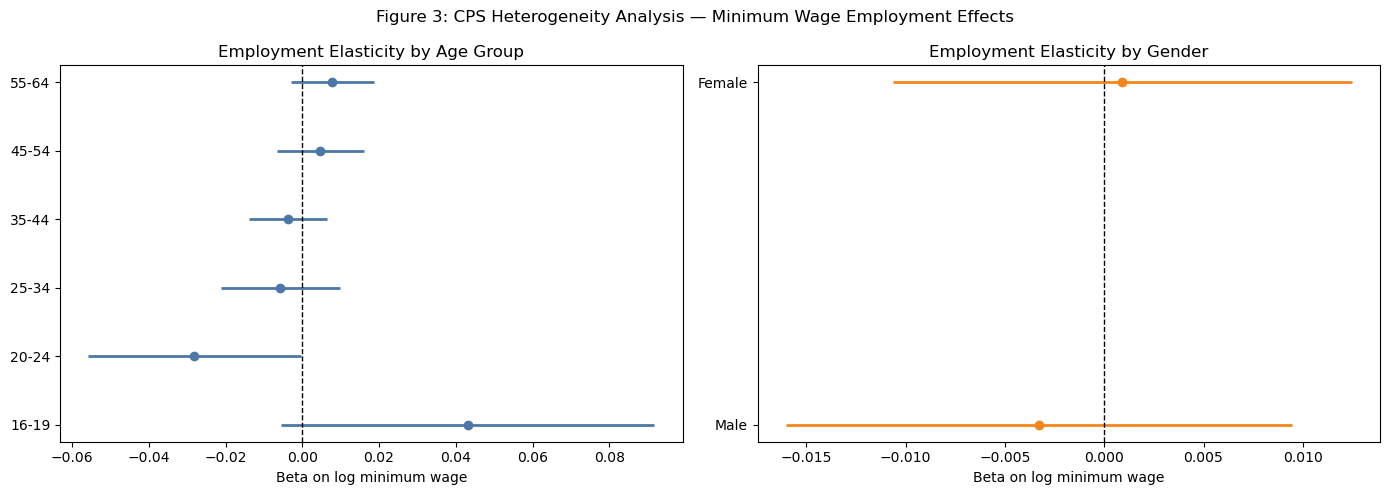

Figure 3 saved.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

# --- Left panel: by age group ---
ax = axes[0]
y = np.arange(len(age_results))
ax.hlines(
    y,
    age_results["beta"] - 1.96 * age_results["se"],
    age_results["beta"] + 1.96 * age_results["se"],
    color="#4C78A8",
    lw=2,
)
ax.plot(age_results["beta"], y, "o", color="#4C78A8")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels(age_results["age_group"])
ax.set_xlabel("Beta on log minimum wage")
ax.set_title("Employment Elasticity by Age Group")

# --- Right panel: by gender ---
ax2 = axes[1]
y2 = np.arange(len(gender_results))
ax2.hlines(
    y2,
    gender_results["beta"] - 1.96 * gender_results["se"],
    gender_results["beta"] + 1.96 * gender_results["se"],
    color="#F58518",
    lw=2,
)
ax2.plot(gender_results["beta"], y2, "o", color="#F58518")
ax2.axvline(0, color="black", ls="--", lw=1)
ax2.set_yticks(y2)
ax2.set_yticklabels(gender_results["gender"])
ax2.set_xlabel("Beta on log minimum wage")
ax2.set_title("Employment Elasticity by Gender")

plt.suptitle(
    "Figure 3: CPS Heterogeneity Analysis — Minimum Wage Employment Effects",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIGURES / "fig3_cps_heterogeneity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved.")